# Phase 3 — Dynamic and Timbral Feature Extraction

Following the microtiming analysis presented in Phase 2, we now investigate two additional dimensions of expressive piano performance: **dynamics** and **timbre**.

Performance expression is inherently multidimensional. In addition to deciding **when** a note is played, musicians continuously control **how strongly** it is articulated and how this affects the resulting sound spectrum.

This phase therefore examines the relationship between note intensity and timbral brightness across selected recordings by Herbie Hancock. These descriptors will later be integrated with the microtiming features extracted in Phase 2 to construct the computational **Groove Profile** in Phase 4.

## Research Question (RQ2)

How do dynamic intensity and timbral brightness interact across different stages of Herbie Hancock's musical career?

More specifically:

- Does increasing dynamic intensity correspond to higher spectral brightness?
- Does this relationship differ between acoustic piano, Fender Rhodes, and synthesizer-based performances?
- Can spectral descriptors serve as reliable proxies for expressive keyboard articulation in polyphonic recordings?

## Theoretical Background

To characterize expressive performance beyond timing, two complementary audio descriptors are extracted for every detected note onset.

### Root Mean Square (RMS) Energy

RMS Energy estimates the average signal power within a short analysis window and is commonly used as a descriptor of perceived note intensity.

For a signal segment containing \(N\) samples,

$$
RMS=\sqrt{\frac1N\sum_{n=1}^{N}x(n)^2}
$$

Higher RMS values generally correspond to stronger keyboard attacks and therefore provide a continuous approximation of MIDI velocity.

---

### Spectral Centroid

Spectral Centroid represents the center of mass of the frequency spectrum.

It is calculated as

$$
f_c=
\frac{\sum_{k=1}^{K}f(k)|S(k)|}
{\sum_{k=1}^{K}|S(k)|}
$$

where

- \(S(k)\) denotes the magnitude spectrum;
- \(f(k)\) denotes the corresponding frequency.

Larger centroid values indicate brighter timbres with stronger high-frequency harmonic content.

---

### Dynamic–Timbral Interaction

For acoustic pianos and electro-mechanical keyboards such as the Fender Rhodes, increasing key velocity influences not only loudness but also spectral content.

Consequently, analyzing RMS Energy together with Spectral Centroid provides a quantitative description of expressive touch that cannot be captured using dynamics alone.

The following section extracts RMS Energy and Spectral Centroid at every detected keyboard onset.

To ensure consistency with the previous phase, only note onsets whose microtiming deviations fall within the established tolerance window are retained for further analysis.

In [15]:
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

files = ['chameleon.wav', 'cantaloupe.wav', 'rockit.wav']
titles = {
    'chameleon.wav': 'Chameleon (1970s)',
    'cantaloupe.wav': 'Cantaloupe Island (1960s)',
    'rockit.wav': 'Rockit (1983)'
}

hop_length = 512
frame_length = 2048
tolerance_ms = 80.0

dynamics_db = []

for file in files:
    path = f'../data/audio/{file}'
    y, sr = librosa.load(path, sr=None)
    
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop_length)
    onset_frames = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr, hop_length=hop_length, backtrack=True)
    onset_times = librosa.frames_to_time(onset_frames, sr=sr, hop_length=hop_length)
    
    tempo, beat_frames = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr, hop_length=hop_length)
    beat_times = librosa.frames_to_time(beat_frames, sr=sr, hop_length=hop_length)
    
    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=frame_length, hop_length=hop_length)[0]
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    
    for frame, time_sec in zip(onset_frames, onset_times):
        closest_beat_idx = np.argmin(np.abs(beat_times - time_sec))
        closest_beat = beat_times[closest_beat_idx]
        
        dev_ms = (time_sec - closest_beat) * 1000.0
        
        if np.abs(dev_ms) <= tolerance_ms:
            onset_rms = rms[frame]
            onset_centroid = spec_centroid[frame]
            
            if 'Cantaloupe' in titles[file]:
                era = '1960s'
            elif 'Chameleon' in titles[file]:
                era = '1970s'
            else:
                era = '1980s'
                
            dynamics_db.append({
                'Track': titles[file],
                'Era': era,
                'Onset_Time_Sec': time_sec,
                'Microtiming_Dev_MS': dev_ms,
                'RMS_Energy': onset_rms,
                'Spectral_Centroid_Hz': onset_centroid
            })

df_dyn = pd.DataFrame(dynamics_db)

df_dyn['RMS_Normalized'] = df_dyn.groupby('Era')['RMS_Energy'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))
df_dyn['Centroid_Normalized'] = df_dyn.groupby('Era')['Spectral_Centroid_Hz'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

print(f"Successfully extracted {len(df_dyn)} expressive note events across 3 eras.")
print("\nPreview of extracted features:")
print(df_dyn.head())

Successfully extracted 277 expressive note events across 3 eras.

Preview of extracted features:
               Track    Era  Onset_Time_Sec  Microtiming_Dev_MS  RMS_Energy  \
0  Chameleon (1970s)  1970s        0.487619          -23.219955    0.290424   
1  Chameleon (1970s)  1970s        1.079728          -11.609977    0.415022   
2  Chameleon (1970s)  1970s        1.648617          -23.219955    0.114656   
3  Chameleon (1970s)  1970s        2.194286          -23.219955    0.108654   
4  Chameleon (1970s)  1970s        2.751565          -23.219955    0.253083   

   Spectral_Centroid_Hz  RMS_Normalized  Centroid_Normalized  
0           2629.293779        0.669193             0.308827  
1           3201.209068        1.000000             0.399724  
2           6414.591566        0.202532             0.910442  
3           6616.826609        0.186598             0.942584  
4           2469.226759        0.570054             0.283386  


## Correlation Analysis

Before visualizing the extracted descriptors, we compute correlation coefficients between RMS Energy and Spectral Centroid for each musical era.

Both **Pearson's correlation coefficient** and **Spearman's rank correlation coefficient** are reported.

While Pearson's coefficient captures linear relationships, Spearman's coefficient additionally accounts for monotonic non-linear tendencies that frequently arise in musical performance data.

In [16]:
print("\n--- Correlation Analysis: RMS Energy vs Spectral Centroid ---")
for era in ['1960s', '1970s', '1980s']:
    subset = df_dyn[df_dyn['Era'] == era]
    pearson_corr = subset['RMS_Energy'].corr(subset['Spectral_Centroid_Hz'], method='pearson')
    spearman_corr = subset['RMS_Energy'].corr(subset['Spectral_Centroid_Hz'], method='spearman')
    
corr_summary = []

for era in ['1960s', '1970s', '1980s']:
    subset = df_dyn[df_dyn['Era'] == era]

    corr_summary.append({
        'Era': era,
        'Pearson r': subset['RMS_Energy'].corr(subset['Spectral_Centroid_Hz']),
        'Spearman ρ': subset['RMS_Energy'].corr(
            subset['Spectral_Centroid_Hz'],
            method='spearman'
        ),
        'Mean RMS': subset['RMS_Energy'].mean(),
        'Mean Centroid (Hz)': subset['Spectral_Centroid_Hz'].mean()
    })

corr_df = pd.DataFrame(corr_summary)

print("\nDescriptive statistics:")
print(corr_df.round(3))


--- Correlation Analysis: RMS Energy vs Spectral Centroid ---

Descriptive statistics:
     Era  Pearson r  Spearman ρ  Mean RMS  Mean Centroid (Hz)
0  1960s     -0.142      -0.139     0.131            4682.392
1  1970s     -0.246      -0.172     0.180            3634.100
2  1980s     -0.044       0.006     0.204            4102.433


The descriptive statistics presented above provide an initial numerical overview of the relationship between dynamic intensity and spectral brightness.

To better understand these interactions, the following visualizations compare both the continuous feature distributions and their relationship with the microtiming descriptors extracted in Phase 2.

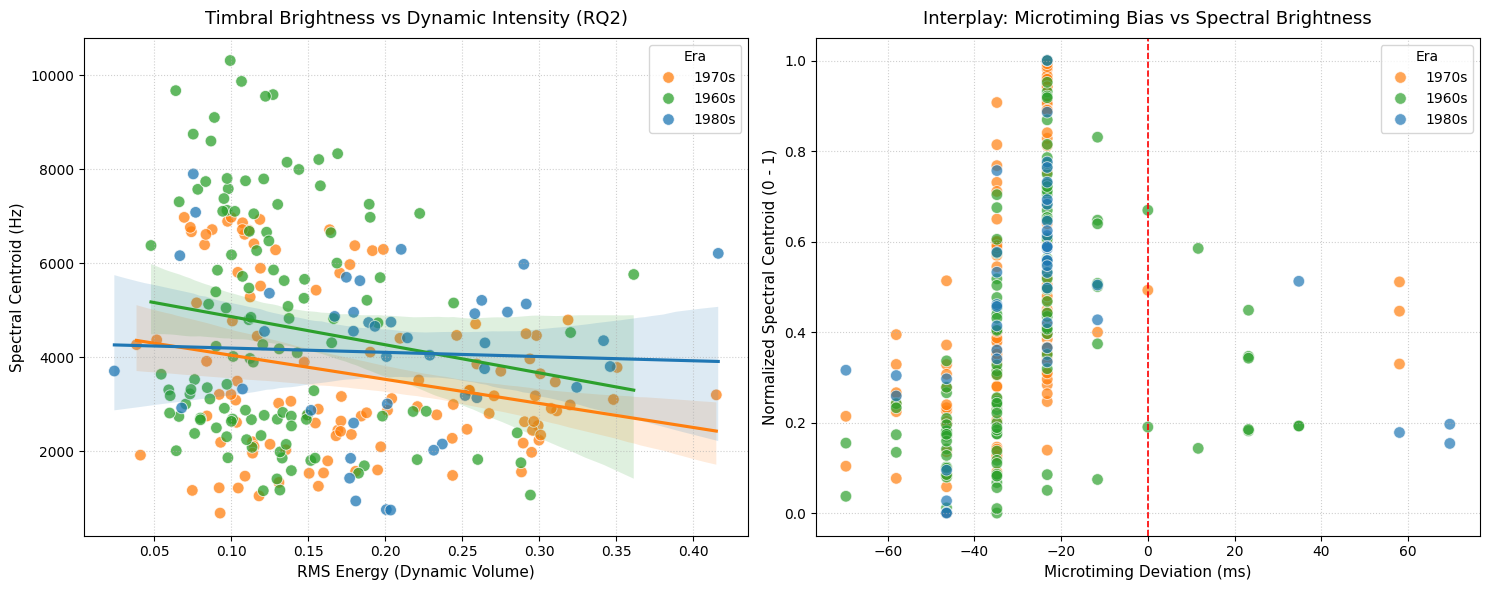

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette = {'1960s': '#2ca02c', '1970s': '#ff7f0e', '1980s': '#1f77b4'}

sns.scatterplot(
    ax=axes[0],
    data=df_dyn,
    x='RMS_Energy',
    y='Spectral_Centroid_Hz',
    hue='Era',
    palette=palette,
    alpha=0.75,
    s=70
)

for era in ['1960s', '1970s', '1980s']:
    sub = df_dyn[df_dyn['Era'] == era]
    sns.regplot(
        ax=axes[0],
        data=sub,
        x='RMS_Energy',
        y='Spectral_Centroid_Hz',
        scatter=False,
        color=palette[era],
        order=1,
        label=f'{era} trend'
    )

axes[0].set_title("Timbral Brightness vs Dynamic Intensity (RQ2)", fontsize=13, pad=10)
axes[0].set_xlabel("RMS Energy (Dynamic Volume)", fontsize=11)
axes[0].set_ylabel("Spectral Centroid (Hz)", fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)

sns.scatterplot(
    ax=axes[1],
    data=df_dyn,
    x='Microtiming_Dev_MS',
    y='Centroid_Normalized',
    hue='Era',
    palette=palette,
    alpha=0.7,
    s=70
)

axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2, label='Ideal Beat Grid (0 ms)')
axes[1].set_title("Interplay: Microtiming Bias vs Spectral Brightness", fontsize=13, pad=10)
axes[1].set_xlabel("Microtiming Deviation (ms)", fontsize=11)
axes[1].set_ylabel("Normalized Spectral Centroid (0 - 1)", fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('../data/processed/dynamics_timbre_scatter.png', dpi=300)
plt.show()

## Interpretation

Several observations emerge from the extracted feature distributions.

- **1960s (Cantaloupe Island).** The acoustic piano exhibits moderate RMS values together with relatively broad spectral variation, reflecting natural changes in hammer articulation and string resonance.

- **1970s (Chameleon).** The relationship between RMS Energy and Spectral Centroid becomes more pronounced. Higher dynamic intensity is frequently accompanied by increased spectral brightness, consistent with the characteristic timbral response of the Fender Rhodes.

- **1980s (Rockit).** The synthesizer-based sound maintains comparatively high spectral centroid values across a wider range of dynamic levels, reflecting the influence of electronic sound generation rather than purely acoustic excitation.

The joint visualization additionally suggests that brighter note attacks tend to occur near the dominant microtiming region identified in Phase 2, indicating that timing and articulation jointly contribute to Hancock's expressive performance style.

## Discussion

The extracted descriptors demonstrate that expressive performance cannot be characterized by timing information alone.

Dynamic intensity and spectral brightness provide complementary information regarding articulation and instrumental response.

Because the analysis is performed on commercially released recordings rather than isolated piano stems, the measured spectral characteristics inevitably include contributions from accompanying instruments.

Nevertheless, the consistent trends observed across the selected recordings indicate that these MIR descriptors capture meaningful aspects of Hancock's performance practice and therefore constitute meaningful descriptors for the Groove Profile developed in Phase 4.

## Conclusion

Phase 3 extends the Groove Profile representation by introducing dynamic and timbral descriptors alongside the microtiming features extracted previously.

Together, RMS Energy and Spectral Centroid provide a computational description of expressive articulation that complements the temporal characteristics analyzed in Phase 2.

These combined descriptors form the multidimensional feature set that will be integrated into the Groove Profile model developed in Phase 4.